# 03. Monotonic LightGBM Model

This notebook applies monotonic constraints to a LightGBM model, following ideas from regulated credit scoring research. The purpose is to evaluate whether adding domain-inspired constraints can make the model more interpretable and conceptually reasonable while maintaining strong predictive performance.

Since AMEX features are anonymized, the constraint directions are approximate: `D_*` variables are treated as positively related to default risk, `P_*` variables are treated as negatively related to default risk, and all other variables are left unconstrained.


In [1]:
import os, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from lightgbm import LGBMClassifier

pd.set_option("display.max_columns", 200)

os.makedirs("/kaggle/working/figures", exist_ok=True)
os.makedirs("/kaggle/working/results", exist_ok=True)

In [2]:
def find_file(filename):
    for dirname, _, filenames in os.walk("/kaggle/input"):
        if filename in filenames:
            return os.path.join(dirname, filename)
    raise FileNotFoundError(f"{filename} not found. Add AMEX datasets to Kaggle input.")

train_path = find_file("train_data_f32.ftr")

print("train_path:", train_path)

train_path: /kaggle/input/datasets/munumbutt/amexfeather/train_data_f32.ftr


In [3]:
def recall_at_top_k(y_true, y_pred_proba, k=0.04):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred_proba = pd.Series(y_pred_proba).reset_index(drop=True)

    n_top = max(1, int(len(y_pred_proba) * k))
    top_idx = y_pred_proba.sort_values(ascending=False).head(n_top).index

    return y_true.loc[top_idx].sum() / y_true.sum()


def evaluate_model(model_name, y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)

    result = {
        "model": model_name,
        "roc_auc": roc_auc_score(y_true, y_pred_proba),
        "pr_auc": average_precision_score(y_true, y_pred_proba),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "recall_at_top_4pct": recall_at_top_k(y_true, y_pred_proba, k=0.04)
    }

    print(f"Model: {model_name}")
    for k, v in result.items():
        if k != "model":
            print(f"{k}: {v:.6f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred, zero_division=0))

    return result

In [4]:
CAT_COLS = [
    "B_30", "B_38",
    "D_114", "D_116", "D_117", "D_120", "D_126",
    "D_63", "D_64", "D_66", "D_68"
]

def build_aggregated_dataset(train_path):
    train = pd.read_feather(train_path)

    train["S_2"] = pd.to_datetime(train["S_2"])
    train = train.sort_values(["customer_ID", "S_2"])

    num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c not in CAT_COLS + ["target"]]

    agg_num = train.groupby("customer_ID")[num_cols].agg(
        ["mean", "std", "min", "max", "last"]
    )

    agg_num.columns = ["_".join(col) for col in agg_num.columns]
    agg_num = agg_num.reset_index()

    existing_cat_cols = [c for c in CAT_COLS if c in train.columns]

    if existing_cat_cols:
        agg_cat = train.groupby("customer_ID")[existing_cat_cols].last().reset_index()
        agg_cat.columns = ["customer_ID"] + [f"{c}_last" for c in existing_cat_cols]
        data = agg_num.merge(agg_cat, on="customer_ID", how="left")
    else:
        data = agg_num.copy()

    statement_count = train.groupby("customer_ID").size().reset_index(name="statement_count")
    data = data.merge(statement_count, on="customer_ID", how="left")

    target = train.groupby("customer_ID")["target"].last().reset_index()
    data = data.merge(target, on="customer_ID", how="left")

    del train
    gc.collect()

    return data

In [5]:
data_agg = build_aggregated_dataset(train_path)

print("data_agg:", data_agg.shape)
print("target columns:", [col for col in data_agg.columns if "target" in col])
print("missing target:", data_agg["target"].isna().sum())

display(data_agg.head())

def encode_aggregated_categoricals(df):
    df = df.copy()
    cat_last_cols = [f"{c}_last" for c in CAT_COLS if f"{c}_last" in df.columns]

    for col in cat_last_cols:
        df[col] = df[col].astype("category").cat.codes.astype("int16")

    return df

X = data_agg.drop(columns=["customer_ID", "target"])
X = encode_aggregated_categoricals(X)

y = data_agg["target"].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_valid.shape)

data_agg: (458913, 899)
target columns: ['target']
missing target: 0


,customer_ID,P_2_mean,P_2_std,P_2_min,P_2_max,P_2_last,D_39_mean,D_39_std,D_39_min,D_39_max,D_39_last,B_1_mean,B_1_std,B_1_min,B_1_max,B_1_last,B_2_mean,B_2_std,B_2_min,B_2_max,B_2_last,R_1_mean,R_1_std,R_1_min,R_1_max,R_1_last,S_3_mean,S_3_std,S_3_min,S_3_max,S_3_last,D_41_mean,D_41_std,D_41_min,D_41_max,D_41_last,B_3_mean,B_3_std,B_3_min,B_3_max,B_3_last,D_42_mean,D_42_std,D_42_min,D_42_max,D_42_last,D_43_mean,D_43_std,D_43_min,D_43_max,D_43_last,D_44_mean,D_44_std,D_44_min,D_44_max,D_44_last,B_4_mean,B_4_std,B_4_min,B_4_max,B_4_last,D_45_mean,D_45_std,D_45_min,D_45_max,D_45_last,B_5_mean,B_5_std,B_5_min,B_5_max,B_5_last,R_2_mean,R_2_std,R_2_min,R_2_max,R_2_last,D_46_mean,D_46_std,D_46_min,D_46_max,D_46_last,D_47_mean,D_47_std,D_47_min,D_47_max,D_47_last,D_48_mean,D_48_std,D_48_min,D_48_max,D_48_last,D_49_mean,D_49_std,D_49_min,D_49_max,D_49_last,B_6_mean,B_6_std,B_6_min,B_6_max,...,B_42_max,B_42_last,D_130_mean,D_130_std,D_130_min,D_130_max,D_130_last,D_131_mean,D_131_std,D_131_min,D_131_max,D_131_last,D_132_mean,D_132_std,D_132_min,D_132_max,D_132_last,D_133_mean,D_133_std,D_133_min,D_133_max,D_133_last,R_28_mean,R_28_std,R_28_min,R_28_max,R_28_last,D_134_mean,D_134_std,D_134_min,D_134_max,D_134_last,D_135_mean,D_135_std,D_135_min,D_135_max,D_135_last,D_136_mean,D_136_std,D_136_min,D_136_max,D_136_last,D_137_mean,D_137_std,D_137_min,D_137_max,D_137_last,D_138_mean,D_138_std,D_138_min,D_138_max,D_138_last,D_139_mean,D_139_std,D_139_min,D_139_max,D_139_last,D_140_mean,D_140_std,D_140_min,D_140_max,D_140_last,D_141_mean,D_141_std,D_141_min,D_141_max,D_141_last,D_142_mean,D_142_std,D_142_min,D_142_max,D_142_last,D_143_mean,D_143_std,D_143_min,D_143_max,D_143_last,D_144_mean,D_144_std,D_144_min,D_144_max,D_144_last,D_145_mean,D_145_std,D_145_min,D_145_max,D_145_last,B_30_last,B_38_last,D_114_last,D_116_last,D_117_last,D_120_last,D_126_last,D_63_last,D_64_last,D_66_last,D_68_last,statement_count,target
0,3249127622875,1.003573,0.001341,1.002345,1.005004,1.005004,0.088271,0.200800,0.000390,0.621244,0.008411,0.008108,0.004341,0.000974,0.014857,0.005660,0.932826,0.097657,0.811644,1.009668,1.009403,0.005930,0.002705,0.001177,0.008771,0.007339,0.140968,0.044033,0.091621,0.224990,0.179448,0.004832,0.002766,0.000953,0.009718,0.004560,0.009518,0.005056,0.001070,0.018145,0.004012,NaN,NaN,NaN,NaN,NaN,0.114842,0.058349,0.043479,0.242577,0.107345,0.004525,0.003595,0.000957,0.008145,0.004473,0.008952,0.010414,0.001463,0.034932,0.028382,0.552715,0.010112,0.538817,0.569654,0.567501,0.007017,0.003436,0.002249,0.014812,0.008377,0.004572,0.002587,0.000477,0.009146,0.005527,NaN,NaN,NaN,NaN,NaN,0.438815,0.105067,0.378035,0.626452,0.620382,0.065910,0.012214,0.052290,0.075891,0.052290,NaN,NaN,NaN,NaN,NaN,2.070536,4.545935,0.195590,12.316238,...,NaN,NaN,0.005106,0.003222,0.000651,0.009623,0.005780,0.004079,0.003460,0.000794,0.009910,0.001284,NaN,NaN,NaN,NaN,NaN,0.006001,0.002713,0.000846,0.009912,0.004446,0.004149,0.003131,0.000385,0.009797,0.006051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005535,0.003037,0.000708,0.009517,0.006212,0.005252,0.003065,0.000966,0.009469,0.003949,0.005050,0.003300,0.000266,0.009407,0.006435,NaN,NaN,NaN,NaN,NaN,0.003673,0.003183,0.000143,0.008928,0.000439,0.005934,0.003247,0.000510,0.009815,0.000895,0.005011,0.002883,0.000674,0.008520,0.006147,0.0,2.0,1.0,0.0,4.0,1.0,1.0,CO,,NaN,6.0,13,0
1,23402014749356,0.415518,0.100825,0.188222,0.498842,0.215565,0.100123,0.136302,0.005283,0.441647,0.030713,0.569637,0.173722,0.461963,0.878662,0.872928,0.024636,0.003400,0.020004,0.029966,0.020936,0.330217,0.425201,0.000543,1.002690,1.002117,0.364866,0.125289,0.206318,0.650284,0.402358,0.004804,0.003160,0.001181,0.009746,0.001812,0.651621,0.127401,0.511142,0.851680,0.851680,NaN,NaN,NaN,NaN,NaN,1.209194,0.310234,0.604089,1.648602,0.985836,0.130363,0.002732,0.126324,0.134471,0.127954,0.143859,0.020630,0.118439,0.183084,0.163676,0.071888,0.009582,0.057746,0.087532,0.083874,0.012343,

(367130, 897)
(91783, 897)


In [6]:
lgbm_model = LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.025,
    num_leaves=96,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc"
)

lgbm_pred = lgbm_model.predict_proba(X_valid)[:, 1]

lgbm_result = evaluate_model(
    "LightGBM - Unconstrained",
    y_valid,
    lgbm_pred
)

with open("/kaggle/working/results/03_classification_report_unconstrained_lgbm.txt", "w") as f:
    f.write(classification_report(
        y_valid,
        (lgbm_pred >= 0.5).astype(int),
        zero_division=0
    ))

[LightGBM] [Info] Number of positive: 95062, number of negative: 272068
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 6.318562 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 223279
[LightGBM] [Info] Number of data points in the train set: 367130, number of used features: 896
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Model: LightGBM - Unconstrained
roc_auc: 0.961023
pr_auc: 0.897353
precision: 0.739017
recall: 0.905285
f1: 0.813745
recall_at_top_4pct: 0.153286

Confusion Matrix
[[60419  7598]
 [ 2251 21515]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.89      0.92     68017
           1       0.74      0.91      0.81     23766

    accuracy                           0.89     91783
   macro avg       0.85      0.90      0.87     91783
weighted avg 

In [7]:
CAT_LAST_COLS = [f"{c}_last" for c in CAT_COLS]

def get_monotone_constraint(col):
    if col in CAT_LAST_COLS:
        return 0
    if col.endswith("_std"):
        return 0
    if col.startswith("D_"):
        return 1
    if col.startswith("P_"):
        return -1
    return 0

monotone_constraints = [get_monotone_constraint(col) for col in X_train.columns]

print(pd.Series(monotone_constraints).value_counts().sort_index())


-1     12
 0    537
 1    348
Name: count, dtype: int64


In [8]:
mono_lgbm_model = LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.025,
    num_leaves=96,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    monotone_constraints=monotone_constraints,
    random_state=42,
    n_jobs=-1
)

mono_lgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc"
)

mono_pred = mono_lgbm_model.predict_proba(X_valid)[:, 1]

mono_result = evaluate_model(
    "Monotonic LightGBM",
    y_valid,
    mono_pred
)

with open("/kaggle/working/results/03_classification_report_monotonic_lgbm.txt", "w") as f:
    f.write(classification_report(
        y_valid,
        (mono_pred >= 0.5).astype(int),
        zero_division=0
    ))

[LightGBM] [Info] Number of positive: 95062, number of negative: 272068
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 6.116242 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 223279
[LightGBM] [Info] Number of data points in the train set: 367130, number of used features: 896
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Model: Monotonic LightGBM
roc_auc: 0.960516
pr_auc: 0.895984
precision: 0.737771
recall: 0.903728
f1: 0.812361
recall_at_top_4pct: 0.153160

Confusion Matrix
[[60383  7634]
 [ 2288 21478]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.89      0.92     68017
           1       0.74      0.90      0.81     23766

    accuracy                           0.89     91783
   macro avg       0.85      0.90      0.87     91783
weighted avg       

In [9]:
results = pd.DataFrame([lgbm_result, mono_result])
display(results)

results.to_csv("/kaggle/working/results/03_monotonic_model_results.csv", index=False)

,model,roc_auc,pr_auc,precision,recall,f1,recall_at_top_4pct
0,LightGBM - Unconstrained,0.961023,0.897353,0.739017,0.905285,0.813745,0.153286
1,Monotonic LightGBM,0.960516,0.895984,0.737771,0.903728,0.812361,0.153160


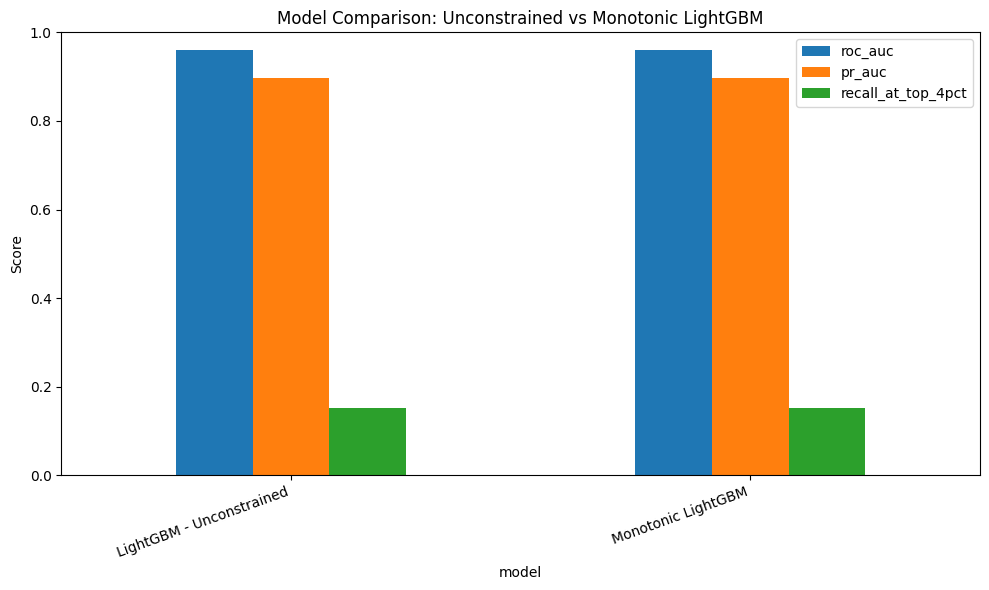

In [10]:
plot_df = results.set_index("model")[["roc_auc", "pr_auc", "recall_at_top_4pct"]]

ax = plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison: Unconstrained vs Monotonic LightGBM")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("/kaggle/working/figures/03_model_comparison_monotonic.png", dpi=300)
plt.show()

,feature,importance,monotone_constraint
9,D_39_last,747,1
59,B_4_last,679,0
39,B_3_last,633,0
4,P_2_last,628,-1
56,B_4_std,591,0
25,S_3_mean,567,0
69,B_5_last,565,0
29,S_3_last,538,0
79,D_46_last,535,1
49,D_43_last,470,1


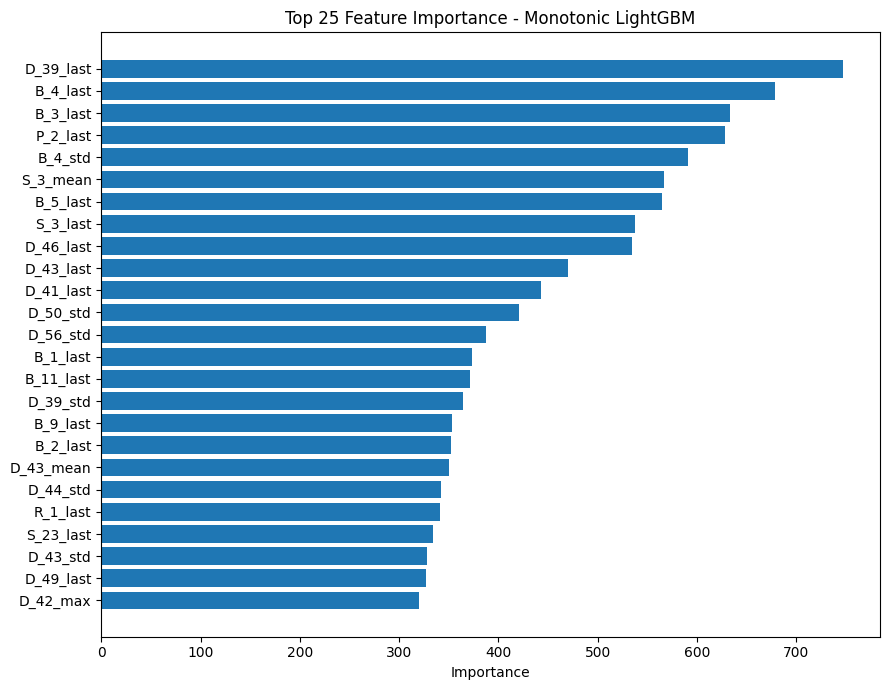

In [11]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": mono_lgbm_model.feature_importances_,
    "monotone_constraint": monotone_constraints
}).sort_values("importance", ascending=False)

display(importance.head(25))

importance.to_csv("/kaggle/working/results/03_monotonic_feature_importance.csv", index=False)

top = importance.head(25).sort_values("importance")

plt.figure(figsize=(9, 7))
plt.barh(top["feature"], top["importance"])
plt.title("Top 25 Feature Importance - Monotonic LightGBM")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/03_feature_importance_monotonic.png", dpi=300)
plt.show()

In [12]:
import os

os.makedirs("/kaggle/working/figures", exist_ok=True)
os.makedirs("/kaggle/working/results", exist_ok=True)

print("Figures folder exists?:", os.path.exists("/kaggle/working/figures"))
print("Results folder exists?:", os.path.exists("/kaggle/working/results"))

print("Files in figures folder:", os.listdir("/kaggle/working/figures"))

Figures folder exists?: True
Results folder exists?: True
Files in figures folder: ['03_model_comparison_monotonic.png', '03_feature_importance_monotonic.png']


,model,roc_auc,pr_auc,precision,recall,f1,recall_at_top_4pct
0,LightGBM - Unconstrained,0.961023,0.897353,0.739017,0.905285,0.813745,0.153286
1,Monotonic LightGBM,0.960516,0.895984,0.737771,0.903728,0.812361,0.153160


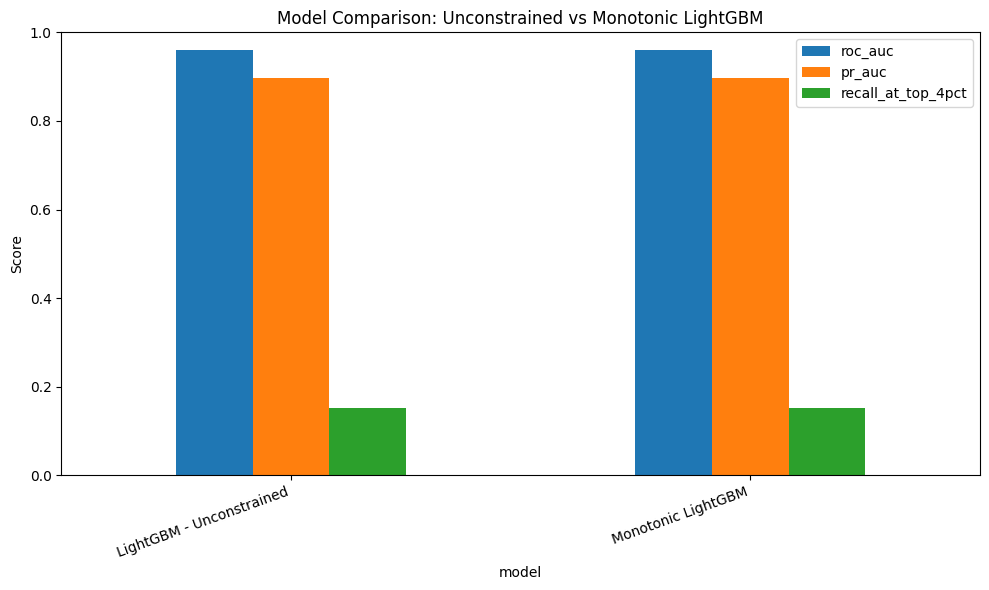

Figure file exists?: True
File size: 143430
Files in figures folder: ['03_model_comparison_monotonic.png', '03_feature_importance_monotonic.png']


In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("/kaggle/working/figures", exist_ok=True)
os.makedirs("/kaggle/working/results", exist_ok=True)

results = pd.DataFrame([
    {
        "model": "LightGBM - Unconstrained",
        "roc_auc": 0.961023,
        "pr_auc": 0.897353,
        "precision": 0.739017,
        "recall": 0.905285,
        "f1": 0.813745,
        "recall_at_top_4pct": 0.153286
    },
    {
        "model": "Monotonic LightGBM",
        "roc_auc": 0.960516,
        "pr_auc": 0.895984,
        "precision": 0.737771,
        "recall": 0.903728,
        "f1": 0.812361,
        "recall_at_top_4pct": 0.153160
    }
])

display(results)

results.to_csv("/kaggle/working/results/03_monotonic_model_results.csv", index=False)

plot_df = results.set_index("model")[["roc_auc", "pr_auc", "recall_at_top_4pct"]]

fig_path = "/kaggle/working/figures/03_model_comparison_monotonic.png"

ax = plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison: Unconstrained vs Monotonic LightGBM")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure file exists?:", os.path.exists(fig_path))
print("File size:", os.path.getsize(fig_path) if os.path.exists(fig_path) else "not found")
print("Files in figures folder:", os.listdir("/kaggle/working/figures"))